In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, mean_absolute_error, mean_squared_error, r2_score, roc_auc_score
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

from tqdm import tqdm
import copy
import json 
import time
import os

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [451]:
df = pd.read_parquet("Data/dipser_dataset.parquet", engine="pyarrow")
df["age_group"] = pd.cut(df["age"], bins=[13, 20, 22, 26, 44]) # bins=[13, 17, 20, 22, 26, 44]
df.head()

,group,time,time_sec,image_path,metadata,subject,experiment,self_labeling emotion,self_labeling attention,labeler_02 attention,labeler_04 attention,labeler_02 emotion,labeler_01 attention,labeler_03 emotion,labeler_03 attention,labeler_01 emotion,labeler_04 emotion,self_labeling emotionfilled,self_labeling attentionfilled,labeler_02 attentionfilled,labeler_04 attentionfilled,labeler_02 emotionfilled,labeler_01 attentionfilled,labeler_03 emotionfilled,labeler_03 attentionfilled,labeler_01 emotionfilled,labeler_04 emotionfilled,samsung_rotation_vector value0_mean,samsung_rotation_vector value0_std,samsung_rotation_vector value1_mean,samsung_rotation_vector value1_std,samsung_rotation_vector value2_mean,samsung_rotation_vector value2_std,samsung_rotation_vector value3_mean,samsung_rotation_vector value3_std,samsung_rotation_vector value4_mean,samsung_rotation_vector value4_std,lsm6dso_gyroscope value0_mean,lsm6dso_gyroscope value0_std,lsm6dso_gyroscope value1_mean,lsm6dso_gyroscope value1_std,lsm6dso_gyroscope value2_mean,lsm6dso_gyroscope value2_std,samsung_linear_acceleration_sensor value0_mean,samsung_linear_acceleration_sensor value0_std,samsung_linear_acceleration_sensor value1_mean,samsung_linear_acceleration_sensor value1_std,samsung_linear_acceleration_sensor value2_mean,samsung_linear_acceleration_sensor value2_std,opt3007_light value0_mean,opt3007_light value0_std,heart_rate,heart_rate_std,accel_magnitude_mean,accel_magnitude_std,gyro_magnitude_mean,gyro_magnitude_std,labeler_05 emotion,labeler_05 attention,labeler_05 emotionfilled,labeler_05 attentionfilled,invalid_reason,gender,age,race,subject_experiment_id,attention,subject_id,age_group
0,group01,2026-05-08 10:40:43.047895,0,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_047895.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_047895.json,subject_01,experiment01,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,-0.109524,0.000163,-0.659717,0.000588,0.632875,0.000495,0.390186,0.000218,246.0,0.0,-0.006022,0.006482,-0.003838,0.003665,-0.000864,0.006845,0.052984,0.034713,-0.132399,0.047077,0.017549,0.043508,63.0,0.0,78.0,NaN,0.155556,0.041540,0.011095,0.005498,NaN,NaN,NaN,NaN,valid,male,26.0,white,group01_experiment01_subject_01,3.25,group01_subject_01,"(22, 26]"
1,group01,2026-05-08 10:40:43.195317,0,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_195317.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_195317.json,subject_01,experiment01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,-0.109485,0.000109,-0.660015,0.000520,0.632620,0.000426,0.390106,0.000225,246.0,0.0,-0.004508,0.005235,-0.004068,0.003267,-0.001026,0.005944,0.053056,0.036979,-0.124020,0.045047,0.012282,0.043478,63.0,0.0,78.0,NaN,0.148634,0.038779,0.009572,0.004378,NaN,NaN,NaN,NaN,valid,male,26.0,white,group01_experiment01_subject_01,3.25,group01_subject_01,"(22, 26]"
2,group01,2026-05-08 10:40:43.295405,0,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_295405.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_295405.json,subject_01,experiment01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,-0.109478,0.000101,-0.660194,0.000514,0.632473,0.000406,0.390043,0.000252,246.0,0.0,-0.004581,0.005193,-0.003897,0.003153,-0.000525,0.005644,0.054420,0.036670,-0.129478,0.044805,0.015730,0.040968,63.0,0.0,78.0,NaN,0.153129,0.038995,0.009384,0.004079,NaN,NaN,NaN,NaN,valid,male,26.0,white,group01_experiment01_subject_01,3.25,group01_subject_01,"(22, 26]"
3,group01,2026-05-08 10:40:43.395835,0,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_395835.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_395835.json,subject_01,experime

In [452]:
df[["attention", "image_path", "age", "gender"]].isna().sum()

attention     0
image_path    0
age           0
gender        0
dtype: int64

In [484]:
SEED = 42
SEQUENCE_LENGTH = 10
MAX_MISSING_VISUAL_FRAMES = 4

# Label-imbalance intervention toggles.
USE_WEIGHTED_LOSS = True
USE_WEIGHTED_SAMPLER = False
LOSS_TYPE = "smooth_l1"  # options: "smooth_l1", "mse", "l1"
WEIGHT_ALPHA = 0.25     # 0=no weighting, 1=full inverse-frequency weighting
ATTENTION_BINS = [2, 2.5, 3, 3.5, 4, 4.75]
ATTENTION_BINS = [2, 2.5, 3, 3.5, 4.75]

STRATIFY_COLUMN = 'age_group'
BATCH_SIZE = 32
NUM_WORKERS = 8

In [454]:
# Keep one frame per second, matching the cached feature setup used in Fusion.
df_sec = (
    df.sort_values(["subject_experiment_id", "time_sec"])
    .groupby(["subject_experiment_id", "time_sec"])
    .first()
    .reset_index())

df_sec.shape

(111754, 69)

In [455]:
reconstructed_sequences = []

for sequence_id, sequence_df in df_sec.groupby("subject_experiment_id"):
    sequence_df = sequence_df.sort_values("time_sec")

    first_second = sequence_df["time_sec"].min()
    last_second = sequence_df["time_sec"].max()

    complete_seconds = pd.DataFrame({
        "time_sec": np.arange(first_second, last_second + 1)
    })

    reconstructed = complete_seconds.merge(
        sequence_df,
        on="time_sec",
        how="left"
    )

    reconstructed["subject_experiment_id"] = sequence_id
    reconstructed["missing_visual_input"] = reconstructed["image_path"].isna().astype(int)
    reconstructed_sequences.append(reconstructed)

temporal_frame_dataset = pd.concat(reconstructed_sequences, ignore_index=True)

In [513]:
temporal_frame_dataset.shape

(121631, 71)

In [456]:
# feature_index = pd.read_parquet("Data/resnet50_features/resnet50_frame_index.parquet")
# feature_store_path = "Data/resnet50_features/resnet50_frame_features.npy"
# VISUAL_FEATURE_DIM = 2048

feature_index = pd.read_parquet('Data/clip_vitl14_features/clip_vitl14_frame_index.parquet')
feature_store_path =  'Data/clip_vitl14_features/clip_vitl14_frame_features.npy'
VISUAL_FEATURE_DIM = 768


feature_row_by_path = dict(zip(feature_index["image_path"], feature_index["feature_row"]))
CNN_FEATURES = feature_store_path.split('/')[-2]

temporal_frame_dataset["feature_row"] = (
    temporal_frame_dataset["image_path"]
    .map(feature_row_by_path)
    .fillna(-1)
    .astype(np.int64))

missing_feature_rows = (
    (temporal_frame_dataset["missing_visual_input"] == 0)
    & (temporal_frame_dataset["feature_row"] == -1)
).sum()

print("Non-missing image rows without cached features:", missing_feature_rows)
temporal_frame_dataset.head()

Non-missing image rows without cached features: 0


,time_sec,subject_experiment_id,group,time,image_path,metadata,subject,experiment,self_labeling emotion,self_labeling attention,labeler_02 attention,labeler_04 attention,labeler_02 emotion,labeler_01 attention,labeler_03 emotion,labeler_03 attention,labeler_01 emotion,labeler_04 emotion,self_labeling emotionfilled,self_labeling attentionfilled,labeler_02 attentionfilled,labeler_04 attentionfilled,labeler_02 emotionfilled,labeler_01 attentionfilled,labeler_03 emotionfilled,labeler_03 attentionfilled,labeler_01 emotionfilled,labeler_04 emotionfilled,samsung_rotation_vector value0_mean,samsung_rotation_vector value0_std,samsung_rotation_vector value1_mean,samsung_rotation_vector value1_std,samsung_rotation_vector value2_mean,samsung_rotation_vector value2_std,samsung_rotation_vector value3_mean,samsung_rotation_vector value3_std,samsung_rotation_vector value4_mean,samsung_rotation_vector value4_std,lsm6dso_gyroscope value0_mean,lsm6dso_gyroscope value0_std,lsm6dso_gyroscope value1_mean,lsm6dso_gyroscope value1_std,lsm6dso_gyroscope value2_mean,lsm6dso_gyroscope value2_std,samsung_linear_acceleration_sensor value0_mean,samsung_linear_acceleration_sensor value0_std,samsung_linear_acceleration_sensor value1_mean,samsung_linear_acceleration_sensor value1_std,samsung_linear_acceleration_sensor value2_mean,samsung_linear_acceleration_sensor value2_std,opt3007_light value0_mean,opt3007_light value0_std,heart_rate,heart_rate_std,accel_magnitude_mean,accel_magnitude_std,gyro_magnitude_mean,gyro_magnitude_std,labeler_05 emotion,labeler_05 attention,labeler_05 emotionfilled,labeler_05 attentionfilled,invalid_reason,gender,age,race,attention,subject_id,age_group,missing_visual_input,feature_row
0,0,group01_experiment01_subject_01,group01,2026-05-08 10:40:43.047895,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_43_047895.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_43_047895.json,subject_01,experiment01,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,6.0,3.0,4.0,3.0,8.0,3.0,9.0,3.0,1.0,7.0,-0.109524,0.000163,-0.659717,0.000588,0.632875,0.000495,0.390186,0.000218,246.0,0.0,-0.006022,0.006482,-0.003838,0.003665,-0.000864,0.006845,0.052984,0.034713,-0.132399,0.047077,0.017549,0.043508,63.0,0.0,78.0,NaN,0.155556,0.041540,0.011095,0.005498,NaN,NaN,NaN,NaN,valid,male,26.0,white,3.25,group01_subject_01,"(22, 26]",0,0
1,1,group01_experiment01_subject_01,group01,2026-05-08 10:40:44.195980,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_44_195980.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_44_195980.json,subject_01,experiment01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,3.0,3.0,3.0,1.0,3.0,9.0,3.0,1.0,7.0,-0.109484,0.000186,-0.663393,0.001822,0.629769,0.001544,0.388982,0.000659,246.0,0.0,-0.017314,0.012752,-0.005738,0.003119,-0.002246,0.006452,0.055115,0.038306,-0.129263,0.050346,0.014268,0.035097,63.0,0.0,77.0,NaN,0.152183,0.044628,0.020409,0.011592,NaN,NaN,NaN,NaN,valid,male,26.0,white,3.00,group01_subject_01,"(22, 26]",0,1
2,2,group01_experiment01_subject_01,group01,2026-05-08 10:40:45.095651,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_45_095651.png,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/metadata/10_40_45_095651.json,subject_01,experiment01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,3.0,3.0,3.0,1.0,3.0,9.0,3.0,1.0,7.0,-0.109878,0.000156,-0.667409,0.000379,0.626474,0.000320,0.387325,0.000218,246.0,0.0,-0.003115,0.007570,-0.002407,0.002732,-0.001051,0.007162,0.053606,0.034863,-0.129119,0.055241,0.013599,0.039643,63.0,0.0,77.0,NaN,0.152138,0.048870,0.010279,0.005109,NaN,NaN,NaN,NaN,valid,male,26.0,white,3.00,group01_subject_01,"(22, 26]",0,2
3,3,group01_experiment01_subject_01,group01,2026-05-08 10:40:46.641389,/home/cfragkiadakis/prjs2039/DIPSER/group01/experiment01/subject_01/images/10_40_46_641389.png,/home/cfragkiadakis/prjs2039/DIPSER/grou

In [457]:
def create_temporal_sequences(frame_df, sequence_length=SEQUENCE_LENGTH):
    sequences = []

    for sequence_id, sequence_df in frame_df.groupby("subject_experiment_id"):
        sequence_df = sequence_df.sort_values("time_sec").reset_index(drop=True)

        if len(sequence_df) < sequence_length:
            continue

        for i in range(sequence_length - 1, len(sequence_df)):
            target = sequence_df.iloc[i]["attention"]

            if pd.isna(target):
                continue

            history = sequence_df.iloc[i - sequence_length + 1:i + 1]
            missing_flags = history["missing_visual_input"].astype(np.float32).values

            if missing_flags.sum() > MAX_MISSING_VISUAL_FRAMES:
                continue

            sequences.append({
                "subject_experiment_id": sequence_id,
                "time_sec": int(sequence_df.iloc[i]["time_sec"]),
                "feature_rows": history["feature_row"].tolist(),
                "missing_flags": missing_flags.tolist(),
                "target": float(target),
            })

    return pd.DataFrame(sequences)

temporal_sequence_df = create_temporal_sequences(temporal_frame_dataset)
temporal_sequence_df.shape

(106446, 5)

In [481]:
subject_info = df[["subject_experiment_id", "subject_id", "age", "gender", "age_group"]].drop_duplicates()

temporal_sequence_df = temporal_sequence_df.merge(
    subject_info,
    on="subject_experiment_id",
    how="left")

temporal_sequence_df[["subject_experiment_id", "subject_id", "gender", "age_group", "target"]].head()

,subject_experiment_id,subject_id,gender,age_group,target
0,group01_experiment01_subject_01,group01_subject_01,male,"(22, 26]",3.00
1,group01_experiment01_subject_01,group01_subject_01,male,"(22, 26]",3.00
2,group01_experiment01_subject_01,group01_subject_01,male,"(22, 26]",3.00
3,group01_experiment01_subject_01,group01_subject_01,male,"(22, 26]",3.00
4,group01_experiment01_subject_01,group01_subject_01,male,"(22, 26]",3.25


In [485]:
subject_df = temporal_sequence_df[["subject_id", STRATIFY_COLUMN]].drop_duplicates()

train_sub, temp_sub = train_test_split(
    subject_df,
    test_size=0.3,
    stratify=subject_df[STRATIFY_COLUMN],
    random_state=SEED
)

val_sub, test_sub = train_test_split(
    temp_sub,
    test_size=0.5,
   # stratify=temp_sub["gender"],
    stratify=temp_sub[STRATIFY_COLUMN],
    random_state=SEED
)

train_subjects = train_sub["subject_id"]
val_subjects = val_sub["subject_id"]
test_subjects = test_sub["subject_id"]

train_df = temporal_sequence_df[temporal_sequence_df["subject_id"].isin(train_subjects)].copy()
val_df = temporal_sequence_df[temporal_sequence_df["subject_id"].isin(val_subjects)].copy()
test_df = temporal_sequence_df[temporal_sequence_df["subject_id"].isin(test_subjects)].copy()

pd.DataFrame({
    "split": ["train", "val", "test"],
    "sequences": [len(train_df), len(val_df), len(test_df)],
    "subjects": [train_df.subject_id.nunique(), val_df.subject_id.nunique(), test_df.subject_id.nunique()],
    "target_mean": [train_df.target.mean(), val_df.target.mean(), test_df.target.mean()],
    "visual_missing_rate": [
        train_df.missing_flags.apply(np.mean).mean(),
        val_df.missing_flags.apply(np.mean).mean(),
        test_df.missing_flags.apply(np.mean).mean(),
    ],
})

,split,sequences,subjects,target_mean,visual_missing_rate
0,train,70966,39,2.938231,0.054935
1,val,17258,9,3.012719,0.043035
2,test,18222,9,2.950239,0.045648


In [486]:
# Quantify target imbalance and create inverse-frequency train weights.
# Weights are learned from train only; val/test weights are diagnostic only.
def add_attention_bin_weights(alpha, train_df, val_df, test_df):
    train_df = train_df.copy()
    val_df = val_df.copy()
    test_df = test_df.copy()

    train_bins = pd.cut(train_df["target"], bins=ATTENTION_BINS, include_lowest=True)
    bin_counts = train_bins.value_counts().sort_index()
    nonzero_counts = bin_counts[bin_counts > 0]

    bin_weights = (len(train_df) / (len(nonzero_counts) * nonzero_counts)) ** alpha

    for split_df in [train_df, val_df, test_df]:
        split_bins = pd.cut(split_df["target"], bins=ATTENTION_BINS, include_lowest=True)
        split_df["attention_bin"] = split_bins.astype(str)
        split_df["sample_weight"] = split_bins.map(bin_weights).astype(float).fillna(1.0)

    train_weight_mean = train_df["sample_weight"].mean()

    for split_df in [train_df, val_df, test_df]:
        split_df["sample_weight"] = split_df["sample_weight"] / train_weight_mean

    normalized_bin_weights = bin_weights / train_weight_mean

    imbalance_table = pd.DataFrame({
        "bin": bin_counts.index.astype(str),
        "train_count": bin_counts.values,
        "weight": [
            float(normalized_bin_weights.get(idx, np.nan))
            for idx in bin_counts.index
        ],
    })

    return train_df, val_df, test_df, imbalance_table

train_df, val_df, test_df, imbalance_table = add_attention_bin_weights(WEIGHT_ALPHA, train_df, val_df, test_df)
display(imbalance_table)

pd.DataFrame({
    "split": ["train", "val", "test"],
    "sequences": [len(train_df), len(val_df), len(test_df)],
    "subjects": [train_df.subject_id.nunique(), val_df.subject_id.nunique(), test_df.subject_id.nunique()],
    "target_mean": [train_df.target.mean(), val_df.target.mean(), test_df.target.mean()],
    "mean_sample_weight": [train_df.sample_weight.mean(), val_df.sample_weight.mean(), test_df.sample_weight.mean()],
})

,bin,train_count,weight
0,"(1.999, 2.5]",16042,1.064480
1,"(2.5, 3.0]",34752,0.877420
2,"(3.0, 3.5]",15550,1.072802
3,"(3.5, 4.75]",4622,1.452930


,split,sequences,subjects,target_mean,mean_sample_weight
0,train,70966,39,2.938231,1.000000
1,val,17258,9,3.012719,1.011586
2,test,18222,9,2.950239,0.995672


In [487]:
class TemporalFeatureDataset(Dataset):

    def __init__(self, sequence_df, feature_store_path):
        self.df = sequence_df.reset_index(drop=True)
        self.feature_store_path = feature_store_path
        self.feature_store = None

    def __len__(self):
        return len(self.df)

    def _features(self):
        if self.feature_store is None:
            self.feature_store = np.load(self.feature_store_path, mmap_mode="r")
        return self.feature_store

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        feature_rows = np.asarray(row["feature_rows"], dtype=np.int64)
        visual_features = np.zeros((len(feature_rows), VISUAL_FEATURE_DIM), dtype=np.float32)

        valid = feature_rows >= 0
        visual_features[valid] = self._features()[feature_rows[valid]]

        visual_features = torch.tensor(visual_features, dtype=torch.float32)
        missing_flags = torch.tensor(row["missing_flags"], dtype=torch.float32)
        target = torch.tensor(row["target"], dtype=torch.float32)
        sample_weight = torch.tensor(row["sample_weight"], dtype=torch.float32)

        return visual_features, missing_flags, target, sample_weight, idx

In [488]:
train_dataset = TemporalFeatureDataset(train_df, feature_store_path)
val_dataset = TemporalFeatureDataset(val_df, feature_store_path)
test_dataset = TemporalFeatureDataset(test_df, feature_store_path)

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": torch.cuda.is_available(),
    "persistent_workers": NUM_WORKERS > 0,
    "prefetch_factor": 4 if NUM_WORKERS > 0 else None,
}
loader_kwargs = {k: v for k, v in loader_kwargs.items() if v is not None}

if USE_WEIGHTED_SAMPLER:
    sampler = torch.utils.data.WeightedRandomSampler(
        weights=torch.tensor(train_df["sample_weight"].values, dtype=torch.double),
        num_samples=len(train_df),
        replacement=True
    )
    train_loader = DataLoader(train_dataset, sampler=sampler, **loader_kwargs)
else:
    train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)

val_loader = DataLoader(val_dataset, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

### Training

In [489]:
class Feature_GRU(nn.Module):

    def __init__(self, feature_dim=VISUAL_FEATURE_DIM, hidden_size=128, dropout=0.3):
        super().__init__()

        self.feature_projection = nn.Sequential(
            nn.Linear(feature_dim + 1, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(0.2),
        )

        self.gru = nn.GRU(
            input_size=512,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )

        self.temporal_norm = nn.LayerNorm(hidden_size)

        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, visual_features, missing_flags):
        missing_flags = missing_flags.unsqueeze(-1)
        features = torch.cat([visual_features, missing_flags], dim=-1)
        features = self.feature_projection(features)

        output, _ = self.gru(features)
       # temporal_features = output.mean(dim=1)
        temporal_features = output[:, -1, :]
        temporal_features = self.temporal_norm(temporal_features)

        prediction = self.regressor(temporal_features)
        return prediction.squeeze(1)

In [490]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    preds_all = []
    labels_all = []
    pbar = tqdm(loader, desc="Training", leave=False)

    for visual_features, missing_flags, labels, sample_weights, _ in pbar:
        visual_features = visual_features.to(device)
        missing_flags = missing_flags.to(device)
        labels = labels.to(device)
        sample_weights = sample_weights.to(device)

        preds = model(visual_features, missing_flags)
        per_sample_loss = criterion(preds, labels)

        if USE_WEIGHTED_LOSS:
            loss = (per_sample_loss * sample_weights).sum() / sample_weights.sum()
        else:
            loss = per_sample_loss.mean()

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        preds_all.extend(preds.detach().cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    train_mae = mean_absolute_error(labels_all, preds_all)
    train_rmse = np.sqrt(mean_squared_error(labels_all, preds_all))

    return total_loss / len(loader), train_mae, train_rmse

In [491]:
def regression_metrics(y_true, y_pred):
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred))
    }


def evaluate(model, loader):
    model.eval()
    preds_all = []
    labels_all = []
    inference_times = []
    pbar = tqdm(loader, desc="Evaluating", leave=False)

    with torch.no_grad():
        for visual_features, missing_flags, labels, sample_weights, _ in pbar:
            visual_features = visual_features.to(device)
            missing_flags = missing_flags.to(device)
            labels = labels.to(device)

            start = time.time()
            preds = model(visual_features, missing_flags)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            end = time.time()

            inference_times.append(end - start)
            preds_all.extend(preds.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    metrics = regression_metrics(labels_all, preds_all)
    return metrics["mae"], metrics["rmse"], np.mean(inference_times)

In [492]:
import copy

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0, model_path=None):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = float("inf")
        self.counter = 0
        self.best_model = None
        self.best_epoch = None
        self.model_path = model_path

    def step(self, metric, model, epoch):
        if metric < self.best_score - self.min_delta:
            self.best_score = metric
            self.counter = 0

            self.best_model = copy.deepcopy(model.state_dict())
            self.best_epoch = epoch

            if self.model_path is not None:
                torch.save(self.best_model, self.model_path)

            return False  # continue

        else:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter}/{self.patience}")

            return self.counter >= self.patience

In [471]:
# LOSS_TYPE = 'smooth_l1'

In [472]:
if LOSS_TYPE == "smooth_l1":
    criterion = nn.SmoothL1Loss(beta=0.5, reduction="none")
    EARLY_STOPPING_METRIC = "mae"
elif LOSS_TYPE == "mse":
    criterion = nn.MSELoss(reduction="none")
    EARLY_STOPPING_METRIC = "rmse"
elif LOSS_TYPE == "l1":
    criterion = nn.L1Loss(reduction="none")
    EARLY_STOPPING_METRIC = "mae"
else:
    raise ValueError(f"Unknown LOSS_TYPE: {LOSS_TYPE}")

print(f"Loss type: {LOSS_TYPE}")
print(f"Early stopping / checkpoint metric: validation {EARLY_STOPPING_METRIC.upper()}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Feature_GRU().to(device)
learning_rate = 1e-4
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.3, patience=3)
model

Loss type: smooth_l1
Early stopping / checkpoint metric: validation MAE


Feature_GRU(
  (feature_projection): Sequential(
    (0): Linear(in_features=769, out_features=512, bias=True)
    (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
  )
  (gru): GRU(512, 128, batch_first=True)
  (temporal_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (regressor): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [473]:
name = f"1.1feature_gru_{LOSS_TYPE}_{CNN_FEATURES}_seq{SEQUENCE_LENGTH}"
if USE_WEIGHTED_LOSS:
    name += f"_weighted_loss_a{WEIGHT_ALPHA}"
if USE_WEIGHTED_SAMPLER:
    name += f"_weighted_sampler_a{WEIGHT_ALPHA}"

model_path = f"models/CNN Temporal/{name}.pt"
model_results = f"results/CNN Temporal/{name}_results.json"
model_figs = f"figs/CNN Temporal/{name}_training_curves.png"
name

'1.1feature_gru_smooth_l1_clip_vitl14_features_seq10_weighted_loss_a0.25'

In [474]:
early_stopping = EarlyStopping(patience=7, model_path=model_path)
NUM_EPOCHS = 50
train_losses = []
train_mae_list, train_rmse_list = [], []
val_mae_list, val_rmse_list = [], []
monitor_metric_list = []

training_start = time.time()

for epoch in range(NUM_EPOCHS):
    train_loss, train_mae, train_rmse = train_one_epoch(model, train_loader)
    val_mae, val_rmse, avg_time = evaluate(model, val_loader)

    if EARLY_STOPPING_METRIC == "rmse":
        monitor_value = val_rmse
    elif EARLY_STOPPING_METRIC == "mae":
        monitor_value = val_mae
    else:
        raise ValueError(f"Unknown early stopping metric: {EARLY_STOPPING_METRIC}")

    train_losses.append(train_loss)
    train_mae_list.append(train_mae)
    train_rmse_list.append(train_rmse)
    val_mae_list.append(val_mae)
    val_rmse_list.append(val_rmse)
    monitor_metric_list.append(monitor_value)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train MAE: {train_mae:.4f} | Train RMSE: {train_rmse:.4f}")
    print(f"Val MAE: {val_mae:.4f} | Val RMSE: {val_rmse:.4f}")
    print(f"Checkpoint metric ({EARLY_STOPPING_METRIC.upper()}): {monitor_value:.4f}")

    scheduler.step(monitor_value)
    stop = early_stopping.step(monitor_value, model, epoch)
    best_epoch = early_stopping.best_epoch

    if stop:
        print("Early stopping triggered")
        break

training_end = time.time()
print('Training time:', training_end - training_start)


Epoch 1
Train Loss: 0.1966
Train MAE: 0.3651 | Train RMSE: 0.4785
Val MAE: 0.3421 | Val RMSE: 0.4395
Checkpoint metric (MAE): 0.3421



Epoch 2
Train Loss: 0.1550
Train MAE: 0.3192 | Train RMSE: 0.4083
Val MAE: 0.3242 | Val RMSE: 0.4176
Checkpoint metric (MAE): 0.3242



Epoch 3
Train Loss: 0.1429
Train MAE: 0.3049 | Train RMSE: 0.3901
Val MAE: 0.3292 | Val RMSE: 0.4221
Checkpoint metric (MAE): 0.3292
EarlyStopping counter: 1/7



Epoch 4
Train Loss: 0.1333
Train MAE: 0.2925 | Train RMSE: 0.3748
Val MAE: 0.3215 | Val RMSE: 0.4208
Checkpoint metric (MAE): 0.3215



Epoch 5
Train Loss: 0.1265
Train MAE: 0.2835 | Train RMSE: 0.3634
Val MAE: 0.3444 | Val RMSE: 0.4435
Checkpoint metric (MAE): 0.3444
EarlyStopping counter: 1/7


...


Epoch 10
Train Loss: 0.0853
Train MAE: 0.2252 | Train RMSE: 0.2927
Val MAE: 0.3244 | Val RMSE: 0.4266
Checkpoint metric (MAE): 0.3244
EarlyStopping counter: 3/7



Epoch 11
Train Loss: 0.0789
Train MAE: 0.2153 | Train RMSE: 0.2807
Val MAE: 0.3256 | Val RMSE: 0.4259
Checkpoint metric (MAE): 0.3256
EarlyStopping counter: 4/7



Epoch 12
Train Loss: 0.0703
Train MAE: 0.2021 | Train RMSE: 0.2641
Val MAE: 0.3377 | Val RMSE: 0.4354
Checkpoint metric (MAE): 0.3377
EarlyStopping counter: 5/7



Epoch 13
Train Loss: 0.0678
Train MAE: 0.1993 | Train RMSE: 0.2593
Val MAE: 0.3431 | Val RMSE: 0.4427
Checkpoint metric (MAE): 0.3431
EarlyStopping counter: 6/7



Epoch 14
Train Loss: 0.0663
Train MAE: 0.1965 | Train RMSE: 0.2560
Val MAE: 0.3351 | Val RMSE: 0.4326
Checkpoint metric (MAE): 0.3351
EarlyStopping counter: 7/7
Early stopping triggered
Training time: 144.96079659461975


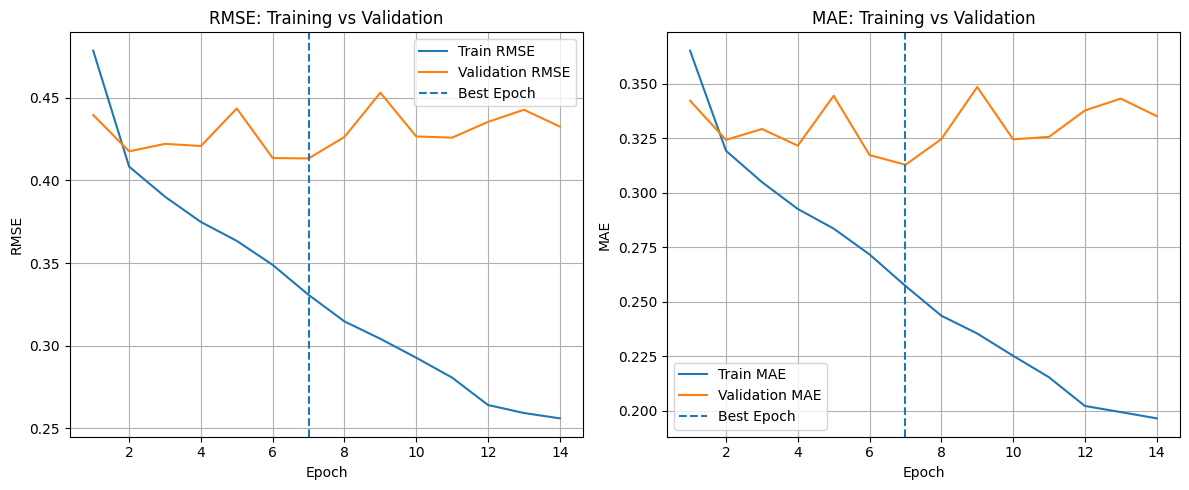

In [475]:
epochs = range(1, len(train_mae_list) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(epochs, train_rmse_list, label="Train RMSE")
ax[0].plot(epochs, val_rmse_list, label="Validation RMSE")
ax[0].axvline(best_epoch + 1, linestyle="--", label="Best Epoch")
ax[0].set_title("RMSE: Training vs Validation")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("RMSE")
ax[0].legend()
ax[0].grid()

ax[1].plot(epochs, train_mae_list, label="Train MAE")
ax[1].plot(epochs, val_mae_list, label="Validation MAE")
ax[1].axvline(best_epoch + 1, linestyle="--", label="Best Epoch")
ax[1].set_title("MAE: Training vs Validation")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("MAE")
ax[1].legend()
ax[1].grid()

plt.tight_layout()
plt.savefig(model_figs, dpi=300, bbox_inches="tight")
plt.show()

### Evaluation on test set

In [476]:
def collect_predictions(model, df, loader):
    model.eval()
    results = []
    total_time = 0
    total_samples = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc="Evaluating")

        for visual_features, missing_flags, labels, sample_weights, idx in pbar:
            visual_features = visual_features.to(device)
            missing_flags = missing_flags.to(device)

            start = time.time()
            preds = model(visual_features, missing_flags)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            end = time.time()

            batch_time = end - start
            total_time += batch_time
            total_samples += visual_features.size(0)

            preds = preds.cpu().numpy()
            labels = labels.cpu().numpy()

            for pred, true, row_idx in zip(preds, labels, idx):
                row = df.iloc[int(row_idx)]
                results.append({
                    "pred": float(pred),
                    "true": float(true),
                    "attention_bin": row["attention_bin"],
                    "gender": row["gender"],
                    "age": row["age"]
                })

    results_df = pd.DataFrame(results)
    metrics = regression_metrics(results_df["true"], results_df["pred"])
    latency_per_batch = total_time / len(loader)
    latency_per_sample = total_time / total_samples

    return results_df, metrics["mae"], metrics["rmse"], latency_per_batch, latency_per_sample

In [505]:
def compute_group_mae(df, group_col):
    group_mae = df.groupby(group_col).apply(
        lambda x: np.mean(np.abs(x["true"] - x["pred"]))
    )
    worst_group = group_mae.max()
    best_group = group_mae.min()
    gap = worst_group - best_group
    return group_mae, worst_group, gap


def compute_fairness_metrics(results_df):
    metrics = {}

    gender_mae, gender_worst, gender_gap = compute_group_mae(results_df, "gender")
    metrics["gender"] = {
        "mae_per_group": {str(k): round(float(v), 5) for k, v in gender_mae.items()},
        "worst_group_mae": round(float(gender_worst), 5),
        "gap": round(float(gender_gap), 5)
    }

    results_df = results_df.copy()
    results_df["age_group"] = pd.cut(results_df["age"], bins=[13, 17, 20, 22, 26, 44])
    age_mae, age_worst, age_gap = compute_group_mae(results_df, "age_group")
    metrics["age"] = {
        "mae_per_group": {str(k): round(float(v), 5) for k, v in age_mae.items()},
        "worst_group_mae": round(float(age_worst), 5),
        "gap": round(float(age_gap), 5)
    }

    return metrics


def compute_attention_bin_metrics(results_df):
    bin_mae = results_df.groupby("attention_bin").apply(
        lambda x: np.mean(np.abs(x["true"] - x["pred"]))
    )
    bin_count = results_df["attention_bin"].value_counts().sort_index()
    return pd.DataFrame({
        "count": bin_count,
        "mae": bin_mae
    }).sort_index()


def compute_prediction_metrics(results_df, tolerance=0.15, binary_threshold=3.0):
    y_true = results_df["true"].to_numpy(dtype=float)
    y_pred = results_df["pred"].to_numpy(dtype=float)

    binary_true = (y_true >= binary_threshold).astype(int)
    binary_pred = (y_pred >= binary_threshold).astype(int)

    try:
        binary_auc = roc_auc_score(binary_true, y_pred)
    except ValueError:
        binary_auc = np.nan

    return {
        "n_samples": int(len(results_df)),
        "mae": round(float(np.mean(np.abs(y_pred - y_true))), 4),
        "rmse": round(float(np.sqrt(np.mean((y_pred - y_true) ** 2))), 4),
        "r2": round(float(r2_score(y_true, y_pred)), 4),
        "tolerant_accuracy": round(float(np.mean(np.abs(y_pred - y_true) <= tolerance)), 4),
        "tolerance": tolerance,
        "one_off_accuracy": round(float(np.mean(np.abs(np.rint(y_pred) - np.rint(y_true)) <= 1)), 4),
        "binary_threshold": binary_threshold,
        "binary_accuracy": round(float(accuracy_score(binary_true, binary_pred)), 4),
        "binary_f1": round(float(f1_score(binary_true, binary_pred, zero_division=0)), 4),
        "binary_roc_auc": None if np.isnan(binary_auc) else round(float(binary_auc), 4),
        "binary_confusion_matrix": confusion_matrix(binary_true, binary_pred).tolist(),
        "true_mean": round(float(np.mean(y_true)), 4),
        "pred_mean": round(float(np.mean(y_pred)), 4),
    }


def append_experiment_results(results, csv_path, jsonl_path):
    flat_row = {
        "run_id": results["run_id"],
        "experiment_name": results["experiment_name"],
        "created_at": results["created_at"],
        "mae": results["mae"],
        "rmse": results["rmse"],
        "tolerant_accuracy": results["tolerant_accuracy"],
        "binary_accuracy": results["binary_accuracy"],
        "binary_f1": results["binary_f1"],
        "binary_roc_auc": results["binary_roc_auc"],
        "one_off_accuracy": results["one_off_accuracy"],
        "r2": results["r2"],
        "gender_worst_group_mae": results["fairness"]["gender"]["worst_group_mae"],
        "gender_gap": results["fairness"]["gender"]["gap"],
        "gender_mae_per_group": json.dumps(results["fairness"]["gender"]["mae_per_group"], sort_keys=True),
        "age_worst_group_mae": results["fairness"]["age"]["worst_group_mae"],
        "age_gap": results["fairness"]["age"]["gap"],
        "age_mae_per_group": json.dumps(results["fairness"]["age"]["mae_per_group"], sort_keys=True),
        "loss_type": results["loss_type"],
        "cnn_features": results["cnn_features"],
        "sequence_length": results["sequence_length"],
        "stratify": results["stratify"],
        "use_weighted_loss": results["use_weighted_loss"],
        "use_weighted_sampler": results["use_weighted_sampler"],
        "weight_alpha": results["weight_alpha"],
        "best_epoch": results["best_epoch"],
        "training_time_sec": results["training_time_sec"],
        "latency_per_sample_ms": results["latency_per_sample_ms"],
    }

    new_row = pd.DataFrame([flat_row])
    if os.path.exists(csv_path):
        experiment_log = pd.read_csv(csv_path)
        experiment_log = pd.concat([experiment_log, new_row], ignore_index=True, sort=False)
        experiment_log.to_csv(csv_path, index=False)
    else:
        new_row.to_csv(csv_path, index=False)

    with open(jsonl_path, "a") as f:
        f.write(json.dumps(results) + "\n")


def baseline_mae(train_df, eval_df):
    mean_pred = train_df["target"].mean()
    median_pred = train_df["target"].median()
    return {
        "mean_baseline_mae": float((eval_df["target"] - mean_pred).abs().mean()),
        "median_baseline_mae": float((eval_df["target"] - median_pred).abs().mean()),
        "train_mean": float(mean_pred),
        "train_median": float(median_pred)
    }

In [478]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Feature_GRU().to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

/scratch-local/cfragkiadakis.23088135/ipykernel_2816185/3308373714.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_locat

Feature_GRU(
  (feature_projection): Sequential(
    (0): Linear(in_features=769, out_features=512, bias=True)
    (1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
  )
  (gru): GRU(512, 128, batch_first=True)
  (temporal_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (regressor): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [506]:
results_df, best_mae, best_rmse, best_latency_batch, best_latency_sample = collect_predictions(model, test_df, test_loader)
fairness_metrics = compute_fairness_metrics(results_df)
attention_bin_metrics = compute_attention_bin_metrics(results_df)
evaluation_metrics = compute_prediction_metrics(results_df)

created_at = time.strftime("%Y-%m-%d %H:%M:%S")
run_id = time.strftime("%Y%m%d_%H%M%S")
results_dir = os.path.dirname(model_results)
os.makedirs(results_dir, exist_ok=True)

results = {
    "run_id": run_id,
    "created_at": created_at,
    "experiment_name": name,
    "model_path": model_path,
    "results_path": model_results,
    **evaluation_metrics,
    "loss_type": LOSS_TYPE,
    "cnn_features": CNN_FEATURES,
    "sequence_length": SEQUENCE_LENGTH,
    "max_missing_visual_frames": MAX_MISSING_VISUAL_FRAMES,
    "attention_bins": ATTENTION_BINS,
    'stratify': STRATIFY_COLUMN,
    "batch_size": BATCH_SIZE,
    "use_weighted_loss": USE_WEIGHTED_LOSS,
    "use_weighted_sampler": USE_WEIGHTED_SAMPLER,
    "weight_alpha": WEIGHT_ALPHA,
    "early_stopping_metric": globals().get("EARLY_STOPPING_METRIC"),
    "best_epoch": None if globals().get("best_epoch") is None else int(best_epoch) + 1,
    "num_epochs_run": len(globals().get("train_losses", [])),
    "learning_rate": globals().get("learning_rate"),
    "training_time_sec": None if "training_start" not in globals() or "training_end" not in globals() else round(float(training_end - training_start), 2),
    "latency_per_batch": round(float(best_latency_batch), 4),
    "latency_per_sample_ms": round(float(best_latency_sample * 1000), 4),
    "train_final_mae": None if not globals().get("train_mae_list") else round(float(train_mae_list[-1]), 4),
    "train_final_rmse": None if not globals().get("train_rmse_list") else round(float(train_rmse_list[-1]), 4),
    "val_final_mae": None if not globals().get("val_mae_list") else round(float(val_mae_list[-1]), 4),
    "val_final_rmse": None if not globals().get("val_rmse_list") else round(float(val_rmse_list[-1]), 4),
    "fairness": fairness_metrics,
    "attention_bin_mae": {
        str(idx): {
            "count": int(row["count"]),
            "mae": round(float(row["mae"]), 5)
        }
        for idx, row in attention_bin_metrics.iterrows()
    }
}

experiment_log_csv = os.path.join(results_dir, "experiment_log.csv")
experiment_log_jsonl = os.path.join(results_dir, "experiment_log.jsonl")

with open(model_results, "w") as f:
    json.dump(results, f, indent=4)

append_experiment_results(results, experiment_log_csv, experiment_log_jsonl)

display(pd.Series(evaluation_metrics))
attention_bin_metrics

Evaluating: 100%|██████████| 570/570 [00:05<00:00, 107.57it/s]
/scratch-local/cfragkiadakis.23088135/ipykernel_2816185/3503493572.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_mae = df.groupby(group_col).apply(
/scratch-local/cfragkiadakis.23088135/ipykernel_2816185/3503493572.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_mae = df.groupby(group_col).apply(
/scratch-local/cfragkiadakis.23088135/ipykernel_2816185/3503493572.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on th

n_samples                                         18222
mae                                                 0.3
rmse                                              0.392
r2                                               0.0593
tolerant_accuracy                                 0.355
tolerance                                          0.15
one_off_accuracy                                 0.9993
binary_threshold                                    3.0
binary_accuracy                                   0.576
binary_f1                                        0.5842
binary_roc_auc                                    0.626
binary_confusion_matrix    [[5069, 3525], [4201, 5427]]
true_mean                                        2.9502
pred_mean                                        3.0247
dtype: object

,count,mae
attention_bin,,
"(1.999, 2.5]",3501,0.575750
"(2.5, 3.0]",9484,0.172692
"(3.0, 3.5]",3983,0.258523
"(3.5, 4.75]",1254,0.624165


In [507]:
print('MAE:', results['mae'])

MAE: 0.3


In [508]:
print("MAE per gender:\n", results['fairness']['gender']['mae_per_group'])
print(f"\nWorst-group MAE: {results['fairness']['gender']['worst_group_mae']}")
print(f"Gap: {results['fairness']['gender']['gap']}")

print('\n')

print("MAE per age:\n", results['fairness']['age']['mae_per_group'])
print(f"\nWorst-group MAE: {results['fairness']['age']['worst_group_mae']}")
print(f"Gap: {results['fairness']['age']['gap']}")

MAE per gender:
 {'female': 0.31461, 'male': 0.19814}

Worst-group MAE: 0.31461
Gap: 0.11647


MAE per age:
 {'(13, 17]': nan, '(17, 20]': 0.34605, '(20, 22]': 0.31271, '(22, 26]': 0.24573, '(26, 44]': 0.275}

Worst-group MAE: 0.34605
Gap: 0.10032


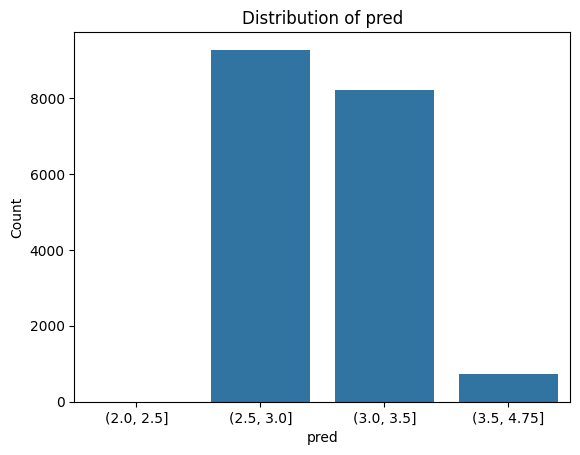

In [509]:
import seaborn as sns

results_df["pred_group"] = pd.cut(results_df["pred"], bins=ATTENTION_BINS)
plt.figure()
sns.countplot(x='pred_group', data=results_df)
plt.title("Distribution of pred")
plt.xlabel("pred")
plt.ylabel("Count")
plt.show()

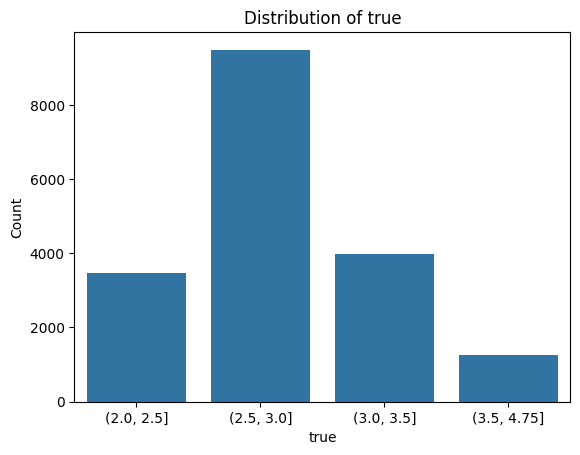

In [510]:
results_df["true_group"] = pd.cut(results_df["true"], bins=ATTENTION_BINS)
plt.figure()
sns.countplot(x='true_group', data=results_df)
plt.title("Distribution of true")
plt.xlabel("true")
plt.ylabel("Count")
plt.show()

In [511]:
from sklearn.metrics import r2_score

print(r2_score(results_df['true'], results_df['pred']))

0.05933815312990587


In [2]:
experiment_log_csv = os.path.join("results/CNN Temporal", "experiment_log.csv")

if os.path.exists(experiment_log_csv):
    experiment_log = pd.read_csv(experiment_log_csv)
    display(experiment_log.sort_values("created_at", ascending=False).reset_index(drop=True).head(5))
else:
    print(f"No experiment log found yet: {experiment_log_csv}")

,run_id,experiment_name,created_at,mae,rmse,tolerant_accuracy,binary_accuracy,binary_f1,binary_roc_auc,one_off_accuracy,r2,gender_worst_group_mae,gender_gap,gender_mae_per_group,age_worst_group_mae,age_gap,age_mae_per_group,loss_type,cnn_features,sequence_length,use_weighted_loss,use_weighted_sampler,weight_alpha,best_epoch,training_time_sec,latency_per_sample_ms,stratify
0,20260524_185818,1.1feature_gru_smooth_l1_clip_vitl14_features_seq10_weighted_loss_a0.25,2026-05-24 18:58:18,0.3000,0.3920,0.3550,0.5760,0.5842,0.6260,0.9993,0.0593,0.31461,0.11647,"{""female"": 0.31461, ""male"": 0.19814}",0.34605,0.10032,"{""(13, 17]"": NaN, ""(17, 20]"": 0.34605, ""(20, 22]"": 0.31271, ""(22, 26]"": 0.24573, ""(26, 44]"": 0.275}",smooth_l1,clip_vitl14_features,10,True,False,0.25,7,144.96,0.0271,age_group
1,20260524_184939,1.1feature_gru_smooth_l1_clip_vitl14_features_seq10_weighted_loss_a0.25,2026-05-24 18:49:39,0.3000,0.3920,0.3550,0.5760,0.5842,0.6260,0.9993,0.0593,0.31461,0.11647,"{""female"": 0.31461, ""male"": 0.19814}",0.34605,0.10032,"{""(13, 17]"": NaN, ""(17, 20]"": 0.34605, ""(20, 22]"": 0.31271, ""(22, 26]"": 0.24573, ""(26, 44]"": 0.275}",smooth_l1,clip_vitl14_features,10,True,False,0.25,7,144.96,0.0272,NaN
2,20260524_145830,1.1feature_gru_smooth_l1_clip_vitl14_features_seq10_weighted_loss_a0.25,2026-05-24 14:58:30,0.2923,0.3754,0.3364,0.5945,0.6101,0.7055,0.9994,0.2037,0.30407,0.01622,"{""female"": 0.28785, ""male"": 0.30407}",0.32452,0.09089,"{""(13, 17]"": 0.23363, ""(17, 20]"": 0.24025, ""(20, 22]"": 0.32452, ""(22, 26]"": 0.29803, ""(26, 44]"": 0.28919}",smooth_l1,clip_vitl14_features,10,True,False,0.25,7,139.44,0.0280,NaN
3,20260524_144612,1.1feature_gru_mse_clip_vitl14_features_seq10_weighted_loss_a0.5,2026-05-24 14:46:12,0.2989,0.3902,0.3553,0.6123,0.6300,0.7151,0.9979,0.1394,0.30382,0.01784,"{""female"": 0.30382, ""male"": 0.28599}",0.34603,0.11854,"{""(13, 17]"": 0.22749, ""(17, 20]"": 0.23472, ""(20, 22]"": 0.34603, ""(22, 26]"": 0.28305, ""(26, 44]"": 0.31115}",mse,clip_vitl14_features,10,True,False,0.50,7,144.44,0.0258,NaN
4,20260524_144149,1.1feature_gru_smooth_l1_clip_vitl14_features_seq1_weighted_loss_a0.5,2026-05-24 14:41:49,0.3130,0.4054,0.3383,0.6112,0.6539,0.6615,0.9976,0.0729,0.31508,0.00759,"{""female"": 0.31508, ""male"": 0.30748}",0.34856,0.10801,"{""(13, 17]"": 0.24055, ""(17, 20]"": 0.24894, ""(20, 22]"": 0.34856, ""(22, 26]"": 0.31355, ""(26, 44]"": 0.32825}",smooth_l1,clip_vitl14_features,1,True,False,0.50,13,197.20,0.0264,NaN
